In [7]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


pd.set_option('display.width', 1000) #formatando o print no terminal

In [8]:
df = pd.read_parquet(os.path.join('data', 'df_cleaned.parquet'))
df = df.dropna()
print(df)

                session_id           user_id   word  word_date  attempts result  time_to_complete_sec   device  session_hour  streak_day  ...     job_role     sector   company_size  orders_food_delivery food_delivery_freq_week  food_delivery_platform  primary_device plays_other_word_games typical_play_time newsletter_subscriber
0     AB38635A07EDE4246661  697E9E150E91BB76  TEMPO 2026-08-02         1    WIN                   449  ANDROID            20           2  ...     ANALISTA   FINANÇAS          MÉDIA                  True                       2                  NENHUM         ANDROID                  False           EVENING                  True
1     67D40A22CBA1A16FD2C5  D7F63DDA905ADAEC  FALHA 2026-08-05         6   LOSE                   232      IOS            19           1  ...     ANALISTA       TECH         GRANDE                  True                       7                   RAPPI             IOS                   True           EVENING                  True
2     3D35

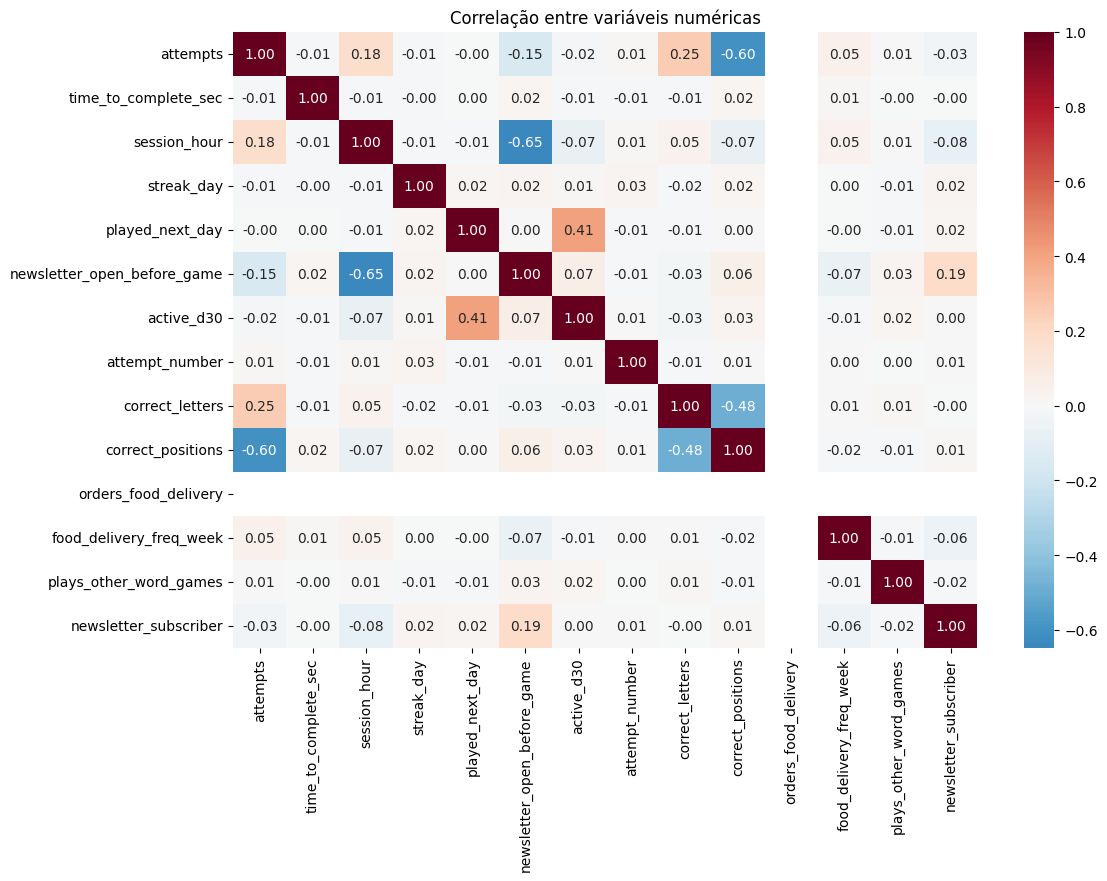

In [9]:
def corr_numerica(df):
    # inclui int, float e bool
    df_num = df.select_dtypes(include=['number', 'bool'])

    corr = df_num.corr()

    plt.figure(figsize=(12,8))
    sns.heatmap(
        corr,
        annot=True,
        cmap='RdBu_r',
        center=0,
        fmt='.2f'
    )

    plt.title('Correlação entre variáveis numéricas')
    plt.show()

    return corr
corr = corr_numerica(df)


A matriz de correlação mostra que a maioria das variáveis apresenta baixa correlação linear, indicando que cada uma captura aspectos distintos do comportamento do usuário. As relações mais relevantes foram entre played_next_day e active_d30 (r=0,41), sugerindo que o retorno no dia seguinte é um bom indicador de retenção de longo prazo; entre attempts e correct_positions (r=-0,60), indicando que usuários que necessitam de mais tentativas tendem a acertar menos posições; e entre session_hour e newsletter_open_before_game (r=-0,65), sugerindo diferenças de comportamento conforme o horário de acesso.